In [3]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
import numpy as np
from scipy.optimize import minimize


#Creating the quantum circuit with parameterized gates
qc = QuantumCircuit(1)
qc.rx(Parameter('theta'), 0)
qc.ry(Parameter('phi'), 0)

#Defining the Pauli operators 
X = SparsePauliOp.from_list([('X', 1)])
Y = SparsePauliOp.from_list([('Y', 1)])
Z = SparsePauliOp.from_list([('Z', 1)])
H = SparsePauliOp.from_list([('X', 0.2), ('Y', 0.5), ('Z', 0.6)])

#Run a estimation with a ansatz value to geta  decent starting point for the optimization. 
#These values were the ones I choose from last semesters final.
estimator = StatevectorEstimator()
ansatz_value = [0.1*np.pi, 0.9*np.pi] 
job = estimator.run([(qc,X,[ansatz_value]), (qc,Y,[ansatz_value]), (qc,Z,[ansatz_value]), (qc,H,[ansatz_value])])
results = job.result()
print(f"Expectation Value of <psi|X|psi>: {results[0].data.evs}")
print(f"Expectation Value of <psi|Y|psi>: {results[1].data.evs}")
print(f"Expectation Value of <psi|Z|psi>: {results[2].data.evs}")
print(f"Expectation Value of <psi|H|psi>: {results[3].data.evs}")

#Minimize function to find the optimal paramater that lead to minimum value of E0 = -0.806226
result = minimize(lambda params: estimator.run([(qc,H,[params])]).result()[0].data.evs[0], ansatz_value, method="COBYLA")
print(f"Optimized value of <psi|H|psi>: {result.fun}")
print(f"Optimized value of theta: {result.x[0]}")
print(f"Optimized value of phi: {result.x[1]}")


Expectation Value of <psi|X|psi>: [-0.29389263]
Expectation Value of <psi|Y|psi>: [-0.30901699]
Expectation Value of <psi|Z|psi>: [-0.9045085]
Expectation Value of <psi|H|psi>: [-0.75599212]
Optimized value of <psi|H|psi>: -0.8062257745253638
Optimized value of theta: 0.32174196399914046
Optimized value of phi: 2.4726552239501087


A:1, B:1, C_in:1
A + B + C_in = 1 + 1 + 1 = 11₂ = 3


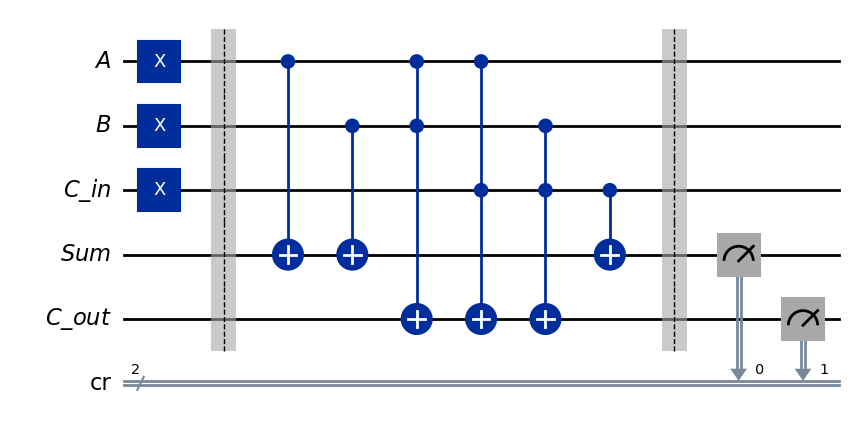

In [4]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import Aer


#Initialize the circuit
A = QuantumRegister(1, 'A')
B = QuantumRegister(1, 'B')
C_in = QuantumRegister(1, 'C_in')
Sum = QuantumRegister(1, 'Sum')
C_out = QuantumRegister(1, 'C_out')
cr = ClassicalRegister(2, 'cr')
qc = QuantumCircuit(A, B, C_in, Sum, C_out, cr)

#Initialize inputs and add them to the circuit
A_value = 1
B_value = 1
C_in_value = 1
if A_value: qc.x(A[0])
if B_value: qc.x(B[0])
if C_in_value: qc.x(C_in[0])
qc.barrier()

#Add the gates
qc.cx(A[0], Sum[0])
qc.cx(B[0], Sum[0])
qc.ccx(A[0],B[0], C_out[0])
qc.ccx(A[0], C_in[0], C_out[0])
qc.ccx(B[0], C_in[0], C_out[0])
qc.cx(C_in[0], Sum[0])
qc.barrier()

#measure the output
qc.measure(Sum[0], cr[0])
qc.measure(C_out[0], cr[1])

#Run the circuit on the qasm simulator to get the results
qasm_sim = Aer.get_backend('qasm_simulator')
tqc = transpile(qc, qasm_sim)
results = qasm_sim.run(tqc).result()
counts = results.get_counts()

#Grab the input values for the sum and carry bits as well as convert the output to a decimal number. 
output = list(counts.keys())[0]
decimal_result = int(output, 2)
print(f"A:{A_value}, B:{B_value}, C_in:{C_in_value}")
print(f"A + B + C_in = {A_value} + {B_value} + {C_in_value} = {output[0]}{output[1]}₂ = {decimal_result}")

qc.draw('mpl')

In [ ]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeCasablancaV2

# Save IBM Quantum account as default
QiskitRuntimeService.save_account( channel="ibm_quantum_platform", token="*************", overwrite=True)

# Run on IBM backend
simulation = False
if simulation:
    backend_IBM = FakeCasablancaV2()
else:
    service = QiskitRuntimeService()
    backend_IBM = service.least_busy(simulator=False, operational=True)
print("Running on current least busy device: ", backend_IBM)

#Initialize the circuit
A = QuantumRegister(1, 'A')
B = QuantumRegister(1, 'B')
C_in = QuantumRegister(1, 'C_in')
Sum = QuantumRegister(1, 'Sum')
C_out = QuantumRegister(1, 'C_out')
cr = ClassicalRegister(2, 'cr')
qc = QuantumCircuit(A, B, C_in, Sum, C_out, cr)

#Initialize inputs and add them to the circuit
A_value = 1
B_value = 1
C_in_value = 1
if A_value: qc.x(A[0])
if B_value: qc.x(B[0])
if C_in_value: qc.x(C_in[0])
qc.barrier()

#Add the gates
qc.cx(A[0], Sum[0])
qc.cx(B[0], Sum[0])
qc.ccx(A[0],B[0], C_out[0])
qc.ccx(A[0], C_in[0], C_out[0])
qc.ccx(B[0], C_in[0], C_out[0])
qc.cx(C_in[0], Sum[0])
qc.barrier()

#measure the output
qc.measure(Sum[0], cr[0])
qc.measure(C_out[0], cr[1])

#Run our circuit on the least busy backend. Monitor the execution of the job in the queue and grab the results
pm = generate_preset_pass_manager(backend=backend_IBM, optimization_level=3)
isa_circuit = pm.run(qc)
sampler = Sampler(backend_IBM)
job = sampler.run([isa_circuit], shots=1024)
job.status()
result = job.result()
counts = result[0].data.cr.get_counts()

#Grab the input values for the sum and carry bits as well as convert the output to a decimal number.
output = list(counts.keys())[0]
decimal_result = int(output, 2)
print(f"A:{A_value}, B:{B_value}, C_in:{C_in_value}")
print(f"A + B + C_in = {A_value} + {B_value} + {C_in_value} = {output[0]}{output[1]}₂ = {decimal_result}")


qiskit_runtime_service.__init__:WARNING:2026-04-05 17:15:04,631: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: CSC766. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-05 17:15:05,015: Loading instance: CSC766, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-05 17:15:06,561: Using instance: CSC766, plan: open


Running on current least busy device:  <IBMBackend('ibm_fez')>
A:1, B:1, C_in:1
A + B + C_in = 1 + 1 + 1 = 11₂ = 3
